## Setup e importaciones

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/product_activity.csv')

print("Dataset cargado")
print(f"Shape: {df.shape}")

Dataset cargado
Shape: (8782, 12)


## Primera fotografia

In [ ]:
#ver primeras 3 filas
print("------Head------")
display(df.head(3))

#mostrar informacion general del dataset
print("\n------Info------")
df.info()

print("\n------Describe------")
display(df.describe())

------Head------


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile



------Info------
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB

------Describe------


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


## Nulos, duplicados y valores unicos

In [12]:
#calcular nulos
print("--- Nulos por Columna ---")
nulos = df.isnull().sum()
#porcentaje de nulos
nulos_pct = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({
    'nulos': nulos,
    '%': nulos_pct
}))


#calcular los duplicados exactos
print("\n--- Duplicados Exactos ---")
print(f"Filas Duplicadas: {df.duplicated().sum()}")


#valores unicos en columnas categoricas
print("\n--- Valores Unicos ---")
for col in ['plan_type','post_category','device_type']:
    print(f"\n {col}:")
    print(df[col].value_counts())


--- Nulos por Columna ---
                   nulos     %
user_id                0  0.00
created_at             0  0.00
country                0  0.00
plan_type              0  0.00
user_age             754  8.59
post_id                0  0.00
post_category          0  0.00
post_created_at        0  0.00
votes_received         0  0.00
user_total_posts       0  0.00
days_since_signup      0  0.00
device_type            0  0.00

--- Duplicados Exactos ---
Filas Duplicadas: 172

--- Valores Unicos ---

 plan_type:
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

 post_category:
post_category
tech           118

## Chequeos logicos de fechas

In [19]:
#parsear fechas temporalmente para medir
#si da error se carga como nulo
df['created_at_tmp'] = pd.to_datetime(df['created_at'], errors='coerce')
df['post_created_at_tmp'] = pd.to_datetime(df['post_created_at'], errors='coerce')

#no parseables
no_parse_signup = df['created_at_tmp'].isnull().sum()
no_parse_post = df['post_created_at_tmp'].isnull().sum()
print(f"Fechas no parseables - created_at: {no_parse_signup}")
print(f"Fechas no parseables - post_created_at: {no_parse_post}")


#posts antes del signup (error logico)
post_antes = (df['post_created_at_tmp'] < df['created_at_tmp']).sum()
print(f"\n Posts antes del signup: {post_antes}")

#recalcular days_since_signup
df['days_since_signup_calc'] = (
    df['post_created_at_tmp'] - df['created_at_tmp']
).dt.days

#comparar con el original
diferencias = (df['days_since_signup'] != df['days_since_signup_calc']).sum()
print(f"Mismatches vs columna original: {diferencias}")

#ver algunos casos donde difieren
print("\n Ejemplos de mismatch:")
mask = df['days_since_signup'] != df['days_since_signup_calc']
display(df[mask][['user_id',
                  'created_at',
                  'post_created_at',
                  'days_since_signup',
                  'days_since_signup_calc']].head(10))


Fechas no parseables - created_at: 1
Fechas no parseables - post_created_at: 1

 Posts antes del signup: 100
Mismatches vs columna original: 4479

 Ejemplos de mismatch:


,user_id,created_at,post_created_at,days_since_signup,days_since_signup_calc
5,U00488,2025-03-19 16:56:05,2025-03-28 12:10:25,9,8.0
7,U01863,2024-12-12 21:40:02,2025-02-02 21:09:32,52,51.0
9,U00880,2024-12-12 23:03:33,2024-12-19 17:52:17,7,6.0
17,U01956,2025-02-19 10:47:45,2025-04-28 01:34:08,68,67.0
18,U01179,2024-08-28 23:29:24,2024-09-14 18:31:09,17,16.0
19,U01871,2025-07-15 19:58:22,2025-08-08 05:42:11,24,23.0
20,U00707,2024-10-07 17:32:12,2024-11-22 14:18:25,46,45.0
21,U00753,2024-02-10 23:28:54,2024-03-03 23:22:03,22,21.0
22,U01754,2025-01-17 07:05:21,2024-12-18 16:05:21,0,-30.0
26,U00485,2025-09-05 15:23:47,2025-09-24 01:27:51,19,18.0


## Fotografia final del estado RAW

In [20]:
raw_total = len(df)

resumen_raw = {
    "Total filas RAW": raw_total,
    "Nulos en user_age": df['user_age'].isnull().sum(),
    "Duplicados exactos": df.duplicated().sum(),
    "Fechas no parseables": (no_parse_post + no_parse_signup),
    "Posts antes del signup": post_antes,
    "Mismatches days_since_signup": diferencias,
    "Categorías fuera de diccionario": df['post_category'].isin(
        ['politics','mistery','sp0rts']).sum(),
    "Planes fuera de diccionario": df['plan_type'].isin(
        ['premium','vip','enterprise+']).sum(),
}

for k, v in resumen_raw.items():
    print(f"{k}: {v}")

Total filas RAW: 8782
Nulos en user_age: 754
Duplicados exactos: 172
Fechas no parseables: 2
Posts antes del signup: 100
Mismatches days_since_signup: 4479
Categorías fuera de diccionario: 3
Planes fuera de diccionario: 3


# Limpieza

In [28]:
#limpiar ruido previo
#convertir todo en minuscula y eliminar espacio
for col in ['plan_type', 'post_category', 'device_type']:
    df[col] = df[col].astype(str).str.strip().str.lower()

#diccionario para typos reales
plan_map = {
    #fuera del dict
    'premium': np.nan, 
    'vip': np.nan, 
    'enterprise+': np.nan
}

category_map = {
    #typos
    'tehc': 'tech', 
    'lfe': 'life', 
    'sport': 'sports', 
    'sporst': 'sports', 
    'sp0rts': 'sports',
    'sciense': 'science', 
    'finanse': 'finance', 
    'gamming': 'gaming', 
    'musc': 'music', 
    'healt': 'health', 
    'educatoin': 'education', 
    'trvael': 'travel',
    #fuera del dict
    'politics': np.nan, 
    'mistery': np.nan
}

device_map = {
    #fuera del dict
    'tablet': np.nan, 
    'console': np.nan, 
    'phone': np.nan
}

print("Diccionarios definidos")

Diccionarios definidos


## Aplicar normalizacion

In [30]:
#hacer una copia
df_work = df.copy()

#aplicar mapeo
df_work['plan_type']     = df_work['plan_type'].replace(plan_map)
df_work['post_category'] = df_work['post_category'].replace(category_map)
df_work['device_type']   = df_work['device_type'].replace(device_map)

#fechas
df_work['created_at']      = pd.to_datetime(df_work['created_at'], errors='coerce')
df_work['post_created_at'] = pd.to_datetime(df_work['post_created_at'], errors='coerce')

#recalcular days_since_signup
df_work['days_since_signup_calc'] = (
    df_work['post_created_at'] - df_work['created_at']
).dt.days

#verificar resultados
print("Planes unicos:", sorted(df_work['plan_type'].dropna().unique()))
print("Dispositivos unicos:", sorted(df_work['device_type'].dropna().unique()))
print("Categorias unicas:", sorted(df_work['post_category'].dropna().unique()))
print(f"\nNaN generados por mapeo:")
print(f"  plan_type:     {df_work['plan_type'].isnull().sum()}")
print(f"  post_category: {df_work['post_category'].isnull().sum()}")
print(f"  device_type:   {df_work['device_type'].isnull().sum()}")

Planes unicos: ['enterprise', 'free', 'pro']
Dispositivos unicos: ['desktop', 'mobile', 'web']
Categorias unicas: ['education', 'finance', 'gaming', 'health', 'life', 'music', 'science', 'sports', 'tech', 'travel']

NaN generados por mapeo:
  plan_type:     3
  post_category: 2
  device_type:   3


## Construccion del Quarantine

In [31]:
#lista de filas
quarantine_rows = []

#razon 1: duplicados exactos
duplicados_idx = df_work[df_work.duplicated(keep='first')].index
for idx in duplicados_idx:
    quarantine_rows.append({'index': idx, 'reason_code': 'duplicate_row'})

#razon 2: post antes del signup
post_antes_idx = df_work[df_work['days_since_signup_calc'] < 0].index
for idx in post_antes_idx:
    quarantine_rows.append({'index': idx, 'reason_code': 'post_before_signup'})

#razon 3: fechas no parseables
fecha_null_idx = df_work[
    df_work['created_at'].isnull() | df_work['post_created_at'].isnull()
].index
for idx in fecha_null_idx:
    quarantine_rows.append({'index': idx, 'reason_code': 'unparseable_date'})

#razon 4: valores fuera de diccionario
for col, code in [('plan_type', 'invalid_plan'), 
                  ('post_category', 'invalid_category'),
                  ('device_type', 'invalid_device')]:
    for idx in df_work[df_work[col].isnull()].index:
        quarantine_rows.append({'index': idx, 'reason_code': code})

#construir df_quarantine
df_q = pd.DataFrame(quarantine_rows)
quarantine_idx = df_q['index'].unique()

df_quarantine = df_work.loc[quarantine_idx].copy()
df_quarantine = df_quarantine.merge(
    df_q.groupby('index')['reason_code'].apply(lambda x: '|'.join(x)).reset_index(),
    left_index=True, right_on='index', how='left'
).drop(columns='index')

df_core = df_work[~df_work.index.isin(quarantine_idx)].copy()

print(f"RAW:        {len(df_work):>6} filas")
print(f"Quarantine: {len(df_quarantine):>6} filas ({len(df_quarantine)/len(df_work)*100:.1f}%)")
print(f"CORE:       {len(df_core):>6} filas ({len(df_core)/len(df_work)*100:.1f}%)")
print(f"\nRazones en Quarantine:")
print(df_q['reason_code'].value_counts())

RAW:          8782 filas
Quarantine:    275 filas (3.1%)
CORE:         8507 filas (96.9%)

Razones en Quarantine:
reason_code
duplicate_row         172
post_before_signup    100
invalid_plan            3
invalid_device          3
unparseable_date        2
invalid_category        2
Name: count, dtype: int64


## Data Quality Report

In [33]:

reporte = {
    'filas_raw':                len(df_work),
    'filas_core':               len(df_core),
    'filas_quarantine':         len(df_quarantine),
    'pct_quarantine':           round(len(df_quarantine) / len(df_work) * 100, 2),
    'duplicados_removidos':     172,
    'post_before_signup':       100,
    'fechas_no_parseables':     2,
    'planes_invalidos':         3,
    'categorias_invalidas':     2,
    'dispositivos_invalidos':   3,
    'nulos_user_age':           754,
    'pct_nulos_user_age':       round(754 / len(df_work) * 100, 2),
    'mismatches_days_signup':   4479,
    'pct_mismatches_days':      round(4479 / len(df_work) * 100, 2),
}

print("        DATA QUALITY REPORT\n\n")
for k, v in reporte.items():
    print(f"  {k:<30} {v}")

print(f"\n  CONCLUSION: El 96.9% del dataset es")
print(f"  analizable. Los mismatches en")
print(f"  days_since_signup (51%) indican que")
print(f"  la columna original no es confiable.")
print(f"  Usar days_since_signup_calc.")

        DATA QUALITY REPORT


  filas_raw                      8782
  filas_core                     8507
  filas_quarantine               275
  pct_quarantine                 3.13
  duplicados_removidos           172
  post_before_signup             100
  fechas_no_parseables           2
  planes_invalidos               3
  categorias_invalidas           2
  dispositivos_invalidos         3
  nulos_user_age                 754
  pct_nulos_user_age             8.59
  mismatches_days_signup         4479
  pct_mismatches_days            51.0

  CONCLUSION: El 96.9% del dataset es
  analizable. Los mismatches en
  days_since_signup (51%) indican que
  la columna original no es confiable.
  Usar days_since_signup_calc.


# Exportar archivos

In [35]:

df_core.to_csv("./data/clean_product_activity.csv", index=False)
df_quarantine.to_csv("./data/quarantine_product_activity.csv", index=False)

print(f"clean_product_activity.csv      -> {len(df_core)} filas")
print(f"quarantine_product_activity.csv -> {len(df_quarantine)} filas")

clean_product_activity.csv      -> 8507 filas
quarantine_product_activity.csv -> 275 filas


## Distribucion de volumen

In [36]:
#usuarios unicos por plan
usuarios_por_plan = (
    df_core.groupby('plan_type')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'usuarios_unicos'})
    .sort_values('usuarios_unicos', ascending=False)
)
print("--- Usuarios unicos por plan ---")
print(usuarios_por_plan.to_string(index=False))

#posts por pais
posts_por_pais = (
    df_core.groupby('country')['post_id']
    .count()
    .reset_index()
    .rename(columns={'post_id': 'total_posts'})
    .sort_values('total_posts', ascending=False)
)
print("\n--- Posts por pais ---")
print(posts_por_pais.to_string(index=False))

#post por categoria
posts_por_categoria = (
    df_core.groupby('post_category')['post_id']
    .count()
    .reset_index()
    .rename(columns={'post_id': 'total_posts'})
    .sort_values('total_posts', ascending=False)
)
print("\n--- Posts por categoria ---")
print(posts_por_categoria.to_string(index=False))

#posts por dispositivo
posts_por_dispositivo = (
    df_core.groupby('device_type')['post_id']
    .count()
    .reset_index()
    .rename(columns={'post_id': 'total_posts'})
    .sort_values('total_posts', ascending=False)
)
print("\n--- Posts por dispositivo ---")
print(posts_por_dispositivo.to_string(index=False))

--- Usuarios unicos por plan ---
 plan_type  usuarios_unicos
      free             1545
       pro              367
enterprise               82

--- Posts por pais ---
country  total_posts
     US         1873
     BR         1600
     AR         1168
     PY          837
     MX          802
     CL          552
     ES          546
     CO          488
     PE          393
     UY          248

--- Posts por categoria ---
post_category  total_posts
         tech         1381
         life         1034
       sports         1017
      science          870
      finance          853
       gaming          833
    education          681
       health          673
        music          673
       travel          492

--- Posts por dispositivo ---
device_type  total_posts
        web         4270
     mobile         3656
    desktop          581


## Engagement por segmento

In [37]:
#definir una funicion para reutilizar
def resumen_votos(df, grupo):
    return (
        df.groupby(grupo)['votes_received']
        .agg(
            total_votos='sum',
            media='mean',
            mediana='median',
            p75=lambda x: x.quantile(0.75),
            p95=lambda x: x.quantile(0.95),
            posts='count'
        )
        .round(2)
        .sort_values('media', ascending=False)
    )

print("--- Votos por plan ---")
display(resumen_votos(df_core, 'plan_type'))

print("\n--- Votos por pais ---")
display(resumen_votos(df_core, 'country'))

print("\n--- Votos por categorias ---")
display(resumen_votos(df_core, 'post_category'))

print("\n--- Votos por dispositivos ---")
display(resumen_votos(df_core, 'device_type'))

--- Votos por plan ---


,total_votos,media,mediana,p75,p95,posts
plan_type,,,,,,
pro,12300,7.65,7.0,10.0,18.0,1607
enterprise,2521,7.57,7.0,10.0,17.0,333
free,43951,6.69,6.0,9.0,16.0,6567



--- Votos por pais ---


,total_votos,media,mediana,p75,p95,posts
country,,,,,,
CO,3574,7.32,6.0,10.0,17.65,488
CL,4036,7.31,6.0,10.0,17.00,552
ES,3810,6.98,6.0,10.0,17.00,546
US,13061,6.97,6.0,9.0,17.00,1873
MX,5584,6.96,6.0,9.0,17.00,802
BR,11023,6.89,6.0,9.0,16.00,1600
AR,7909,6.77,6.0,9.0,16.00,1168
UY,1677,6.76,6.0,9.0,15.00,248
PY,5525,6.60,6.0,9.0,15.20,837



--- Votos por categorias ---


,total_votos,media,mediana,p75,p95,posts
post_category,,,,,,
tech,10616,7.69,7.0,10.0,18.0,1381
science,6564,7.54,6.0,10.0,19.0,870
gaming,5986,7.19,6.0,9.0,18.0,833
finance,5953,6.98,6.0,9.0,17.0,853
travel,3384,6.88,6.0,9.0,17.0,492
education,4625,6.79,6.0,9.0,16.0,681
sports,6685,6.57,6.0,9.0,15.0,1017
health,4345,6.46,6.0,9.0,15.0,673
music,4231,6.29,5.0,9.0,15.0,673



--- Votos por dispositivos ---


,total_votos,media,mediana,p75,p95,posts
device_type,,,,,,
desktop,4086,7.03,6.0,10.0,16.0,581
web,29722,6.96,6.0,9.0,17.0,4270
mobile,24964,6.83,6.0,9.0,17.0,3656


## Evento vs Usuario

In [38]:
#promedio por fila (nivel evento)
media_por_fila = df_core['votes_received'].mean().round(2)

#promedio por usuario (nivel entidad)
media_por_usuario = (
    df_core.groupby('user_id')['votes_received']
    .mean()
    .mean()
    .round(2)
)

print(f"Promedio de votos por fila (evento):   {media_por_fila}")
print(f"Promedio de votos por usuario:         {media_por_usuario}")
print(f"Diferencia:                            {round(media_por_fila - media_por_usuario, 2)}")

#por que difieren: ver distribucion de posts por usuario
posts_por_usuario = df_core.groupby('user_id')['post_id'].count()

print(f"\n=== DISTRIBUCION DE POSTS POR USUARIO ===")
print(f"Media de posts por usuario:   {posts_por_usuario.mean().round(2)}")
print(f"Mediana de posts por usuario: {posts_por_usuario.median()}")
print(f"Max posts de un usuario:      {posts_por_usuario.max()}")
print(f"Min posts de un usuario:      {posts_por_usuario.min()}")
print(f"\nUsuarios con 1 solo post:     {(posts_por_usuario == 1).sum()}")
print(f"Usuarios con 10+ posts:       {(posts_por_usuario >= 10).sum()}")

Promedio de votos por fila (evento):   6.91
Promedio de votos por usuario:         6.9
Diferencia:                            0.01

=== DISTRIBUCION DE POSTS POR USUARIO ===
Media de posts por usuario:   4.27
Mediana de posts por usuario: 3.0
Max posts de un usuario:      39
Min posts de un usuario:      1

Usuarios con 1 solo post:     498
Usuarios con 10+ posts:       173


## Concentracion

In [39]:
total_usuarios = df_core['user_id'].nunique()
top_1pct_n = max(1, int(total_usuarios * 0.01))

#usuarios con mas posts
top_usuarios_posts = (
    df_core.groupby('user_id')['post_id']
    .count()
    .sort_values(ascending=False)
    .head(top_1pct_n)
    .index
)

#usuarios con mas votos
top_usuarios_votos = (
    df_core.groupby('user_id')['votes_received']
    .sum()
    .sort_values(ascending=False)
    .head(top_1pct_n)
    .index
)

pct_posts_top = (
    df_core[df_core['user_id'].isin(top_usuarios_posts)]['post_id'].count() 
    / len(df_core) * 100
)

pct_votos_top = (
    df_core[df_core['user_id'].isin(top_usuarios_votos)]['votes_received'].sum() 
    / df_core['votes_received'].sum() * 100
)

print(f"Total usuarios unicos: {total_usuarios}")
print(f"Top 1% = {top_1pct_n} usuarios")
print(f"\n% de posts que genera el top 1%:  {pct_posts_top:.1f}%")
print(f"% de votos que concentra el top 1%: {pct_votos_top:.1f}%")

Total usuarios unicos: 1994
Top 1% = 19 usuarios

% de posts que genera el top 1%:  5.8%
% de votos que concentra el top 1%: 6.2%


## Tendencia temporal

In [43]:
df_core['mes'] = df_core['post_created_at'].dt.to_period('M')

tendencia = (
    df_core.groupby('mes')
    .agg(
        total_posts=('post_id', 'count'),
        total_votos=('votes_received', 'sum'),
        media_votos=('votes_received', 'mean')
    )
    .round(2)
)

print("--- Actividad por mes ---")
print(tendencia.to_string())

--- Actividad por mes ---
         total_posts  total_votos  media_votos
mes                                           
2024-01          195         1376         7.06
2024-02          370         2605         7.04
2024-03          387         2565         6.63
2024-04          394         2750         6.98
2024-05          456         3101         6.80
2024-06          389         2636         6.78
2024-07          380         2711         7.13
2024-08          388         2601         6.70
2024-09          304         2030         6.68
2024-10          353         2555         7.24
2024-11          364         2385         6.55
2024-12          374         2540         6.79
2025-01          398         2723         6.84
2025-02          299         2122         7.10
2025-03          340         2320         6.82
2025-04          382         2566         6.72
2025-05          354         2567         7.25
2025-06          316         2088         6.61
2025-07          349         2345 

## Product Decisions

In [45]:
decisions = """
=== SEGMENTO A PRIORIZAR ===
Usuarios Pro:
    - La media de votos pro es 7.65 vs 6.69 en free (+14%)
    - Solo 367 usuarios pro vs 1545 free (18% de la base paga)
    - El diferencial de engagement es bajo, lo que sugiere que
      los features pro noestan generando suficiente valor diferencial
      o que los usuarios pro son mas comprometidos por naturaleza
    - Accion: auditar que features pro se usan y cuales no,
      evaluar si algun feature puede moverse a free para
      estudiar su impacto en conversion

=== LO QUE MENTIA ANTES DE LIMPIAR ===
    - days_since_signup tenia 51% de valores incorrectos
      cualquier segmentacion por antiguedad estaba levemente
      inflada (1 dia de diferencia sistematica)
    - plan_type tenia variantes sucias que inflaban
      artificialmente el conteo de cada categoria de plan
    - Se detectaron 100 posts pre-registro, lo que significa
      que metricas de actividad temprana estaban contaminadas
      con eventos sin usuario valido asociado

=== DATOS NUEVOS PARA TRACKING ===
    - Tipo de interaccion por post (like, share, comment, save):
      con solo votes_received no se puede distinguir consumo
      real de contenido vs scroll pasivo, critico para
      algoritmos de recomendacion
    - Tiempo de sesion promedio: permite conectar duracion
      de uso con engagement real, pregunta que este dataset
      no pudo responder

=== ACCIONES CONCRETAS ===
    Accion 1: Programa de activacion post-primer-post
        - Respaldo: 498 usuarios con 1 solo post (25% de la base)
        - Problema de activacion, no de adquisicion
        - Limitacion: sin datos de sesion ni motivo de abandono

    Accion 2: Invertir en contenido tech y science
        - Respaldo: tech lidera en votos (7.69) y volumen (1381)
        - Science tiene alta media (7.54) con menor volumen,
          audiencia de nicho muy engaged
        - Limitacion: sin datos de retencion ni conversion a pro

=== LIMITACIONES DEL DATASET ===
    - Sin datos de revenue por plan (no se puede calcular LTV)
    - Sin datos de sesion (no se puede medir retencion real)
    - Sin datos de churn
    - Sin tipos de interaccion detallados
    - Periodo parcial en enero 2024 y posiblemente diciembre 2025
    - user_age con 8.6% de nulos sin causa conocida
"""

print(decisions)


=== SEGMENTO A PRIORIZAR ===
Usuarios Pro:
    - La media de votos pro es 7.65 vs 6.69 en free (+14%)
    - Solo 367 usuarios pro vs 1545 free (18% de la base paga)
    - El diferencial de engagement es bajo, lo que sugiere que
      los features pro noestan generando suficiente valor diferencial
      o que los usuarios pro son mas comprometidos por naturaleza
    - Accion: auditar que features pro se usan y cuales no,
      evaluar si algun feature puede moverse a free para
      estudiar su impacto en conversion

=== LO QUE MENTIA ANTES DE LIMPIAR ===
    - days_since_signup tenia 51% de valores incorrectos
      cualquier segmentacion por antiguedad estaba levemente
      inflada (1 dia de diferencia sistematica)
    - plan_type tenia variantes sucias que inflaban
      artificialmente el conteo de cada categoria de plan
    - Se detectaron 100 posts pre-registro, lo que significa
      que metricas de actividad temprana estaban contaminadas
      con eventos sin usuario valido as

## Visualizaciones

C:\Users\espin\AppData\Local\Temp\ipykernel_2172\1229881333.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(planes, labels=['free','pro','enterprise'])


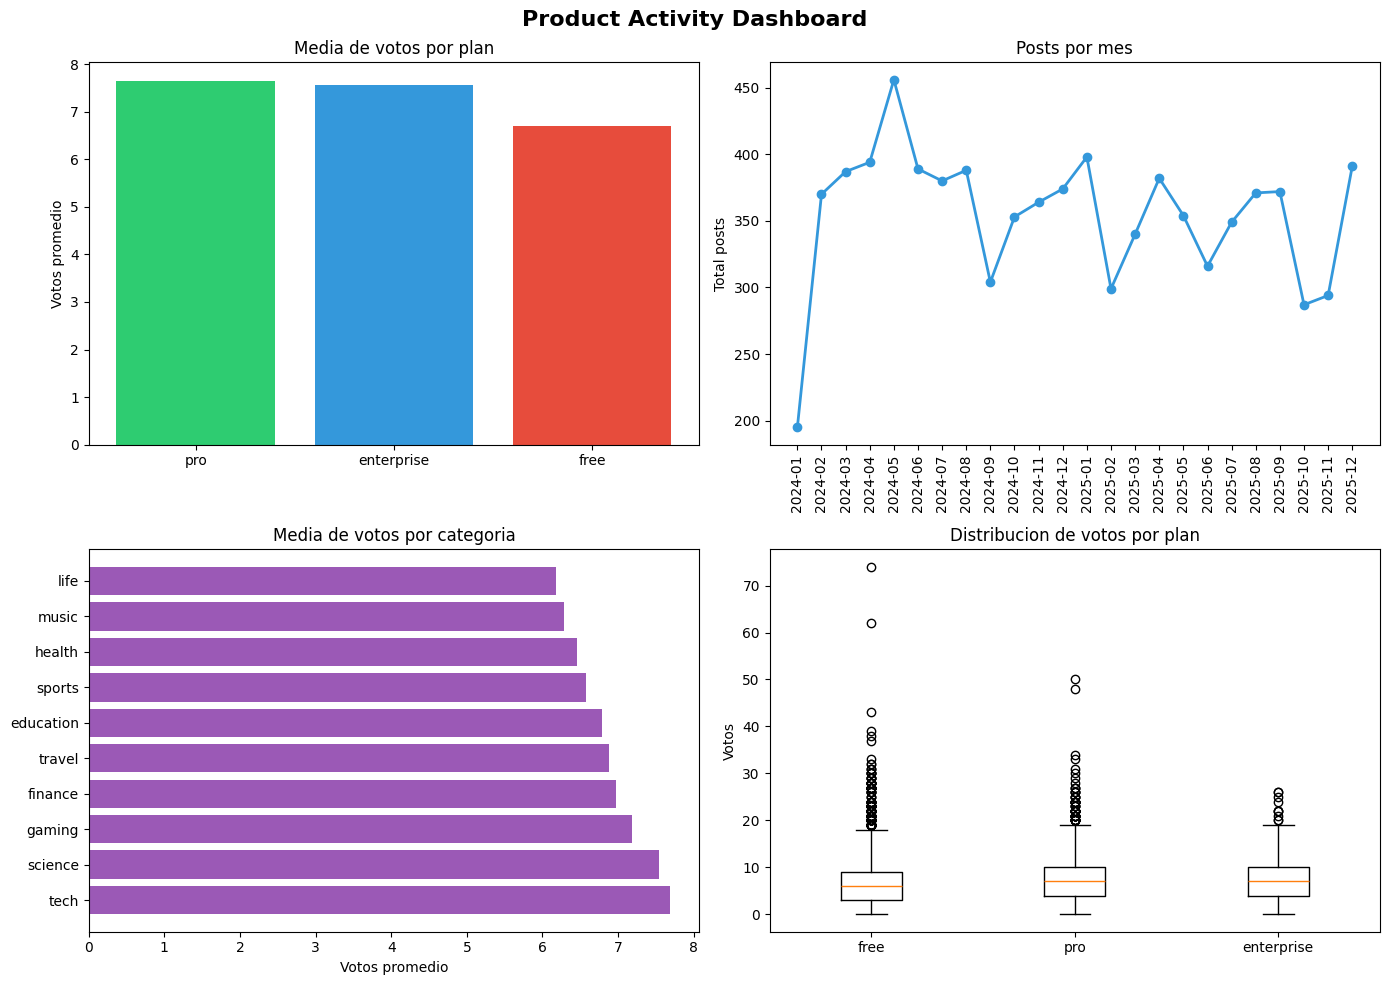

Dashboard exportado como dashboard.png


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Product Activity Dashboard', fontsize=16, fontweight='bold')

#votos por plan
votos_plan = df_core.groupby('plan_type')['votes_received'].mean().sort_values(ascending=False)
axes[0,0].bar(votos_plan.index, votos_plan.values, color=['#2ecc71','#3498db','#e74c3c'])
axes[0,0].set_title('Media de votos por plan')
axes[0,0].set_ylabel('Votos promedio')

#posts por mes
posts_mes = df_core.groupby('mes')['post_id'].count()
axes[0,1].plot(posts_mes.index.astype(str), posts_mes.values, marker='o', linewidth=2, color='#3498db')
axes[0,1].set_title('Posts por mes')
axes[0,1].set_ylabel('Total posts')
axes[0,1].tick_params(axis='x', rotation=90)

#votos por categorias
votos_cat = df_core.groupby('post_category')['votes_received'].mean().sort_values(ascending=False)
axes[1,0].barh(votos_cat.index, votos_cat.values, color='#9b59b6')
axes[1,0].set_title('Media de votos por categoria')
axes[1,0].set_xlabel('Votos promedio')

#boxplot votos por plan
planes = [df_core[df_core['plan_type']==p]['votes_received'].values for p in ['free','pro','enterprise']]
axes[1,1].boxplot(planes, labels=['free','pro','enterprise'])
axes[1,1].set_title('Distribucion de votos por plan')
axes[1,1].set_ylabel('Votos')

plt.tight_layout()
plt.savefig('./data/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard exportado como dashboard.png")

## Exportar metricas

In [ ]:
metrics_summary = pd.DataFrame([
    #volumen
    {'categoria': 'volumen', 'metrica': 'total_posts_core', 'valor': len(df_core)},
    {'categoria': 'volumen', 'metrica': 'usuarios_unicos', 'valor': df_core['user_id'].nunique()},
    {'categoria': 'volumen', 'metrica': 'usuarios_free', 'valor': 1545},
    {'categoria': 'volumen', 'metrica': 'usuarios_pro', 'valor': 367},
    {'categoria': 'volumen', 'metrica': 'usuarios_enterprise', 'valor': 82},
    #engagement
    {'categoria': 'engagement', 'metrica': 'media_votos_global', 'valor': round(df_core['votes_received'].mean(), 2)},
    {'categoria': 'engagement', 'metrica': 'mediana_votos_global', 'valor': df_core['votes_received'].median()},
    {'categoria': 'engagement', 'metrica': 'media_votos_free', 'valor': 6.69},
    {'categoria': 'engagement', 'metrica': 'media_votos_pro', 'valor': 7.65},
    {'categoria': 'engagement', 'metrica': 'media_votos_enterprise', 'valor': 7.57},
    #concentracion
    {'categoria': 'concentracion', 'metrica': 'pct_posts_top1pct', 'valor': 5.8},
    {'categoria': 'concentracion', 'metrica': 'pct_votos_top1pct', 'valor': 6.2},
    {'categoria': 'concentracion', 'metrica': 'usuarios_1_solo_post', 'valor': 498},
    #calidad
    {'categoria': 'calidad', 'metrica': 'pct_quarantine', 'valor': 3.13},
    {'categoria': 'calidad', 'metrica': 'pct_nulos_user_age', 'valor': 8.59},
    {'categoria': 'calidad', 'metrica': 'pct_mismatches_days', 'valor': 51.0},
])

metrics_summary.to_csv('metrics_summary.csv', index=False)
print("metrics_summary.csv exportado")
print(f"{len(metrics_summary)} metricas guardadas")

metrics_summary.csv exportado
16 metricas guardadas
